In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import qcodes as qc

from qcodes.dataset import (
    LinSweep,
    Measurement,
    dond,
    experiments,
    initialise_or_create_database_at,
    load_by_run_spec,
    load_or_create_experiment,
    plot_dataset,
)

from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

import scienceplots



In [2]:
plt.style.use(['science','no-latex'])

In [3]:
db_path = r"C:\Users\emile\Thesis\Data_processing\RT_power_sweep_2.0\RT_power_sweep_full.db"

qc.initialise_or_create_database_at(db_path)

experiment = qc.load_or_create_experiment(experiment_name="power sweep RT", sample_name="Marcus old sample")

In [4]:
#experiment

-0.3255 -0.3235
-0.3242
[ 2.8   2.72  2.64  2.56  2.48  2.4   2.32  2.24  2.16  2.08  2.    1.92
  1.84  1.76  1.68  1.6   1.52  1.44  1.36  1.28  1.2   1.12  1.04  0.96
  0.88  0.8   0.72  0.64  0.56  0.48  0.4   0.32  0.24  0.16  0.08  0.
 -0.08 -0.16 -0.24 -0.32 -0.4  -0.48 -0.56 -0.64 -0.72 -0.8  -0.88 -0.96
 -1.04 -1.12 -1.2  -1.28 -1.36 -1.44 -1.52 -1.6  -1.68 -1.76 -1.84 -1.92
 -2.   -2.08 -2.16 -2.24 -2.32 -2.4  -2.48 -2.56 -2.64 -2.72 -2.8  -2.88
 -2.96 -3.04 -3.12 -3.2  -3.28 -3.36 -3.44 -3.52 -3.6  -3.68 -3.76 -3.84
 -3.92 -4.   -4.08 -4.16 -4.24 -4.32 -4.4  -4.48 -4.56 -4.64 -4.72 -4.8
 -4.88 -4.96 -5.04 -5.12 -5.2 ]


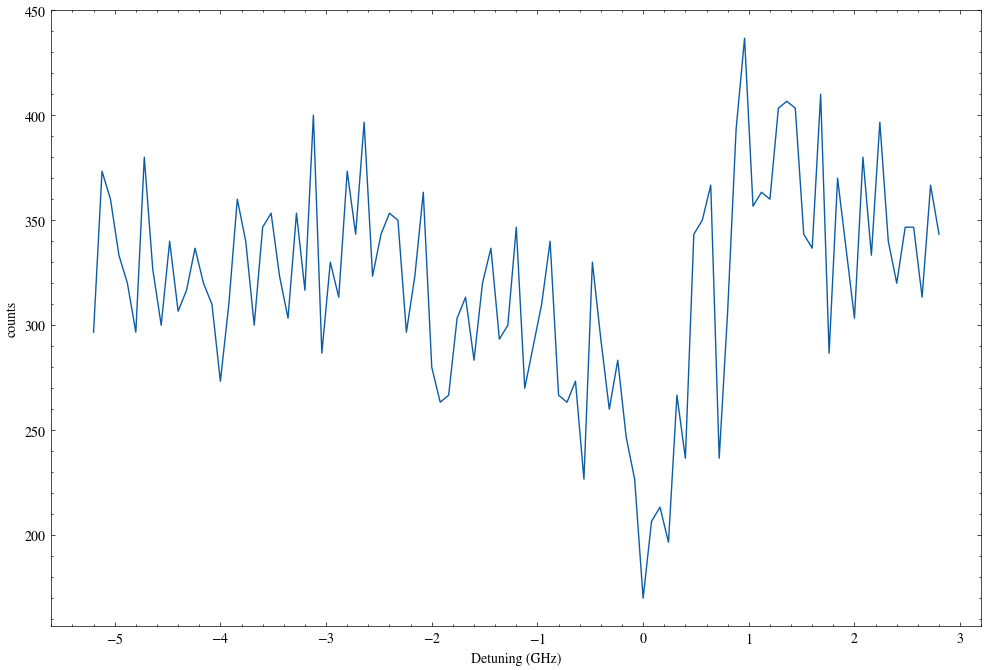

In [5]:
def load_and_extract_with_detune(run_id):
    dataset = qc.load_by_run_spec(experiment_name="power sweep RT", captured_run_id=run_id)
    data = dataset.get_parameter_data()
    countrate = data["countrate"]["countrate"]
    voltage = data["countrate"]["keysight_ch2_source_voltage"]
    power = data["pm_mobile_power"]["pm_mobile_power"]

    # convert voltage to detuning for x axis 
    print(voltage.min(), voltage.max())
    v_res_arg = np.argmin(countrate)
    v_res = voltage[v_res_arg]
    print(v_res)

    detuning_x = ((voltage - v_res)) * 4000 #  3550 
    print(detuning_x)
    return countrate, voltage, power, detuning_x


countrate, voltage, power, detuning_x = load_and_extract_with_detune(583)

plt.figure(figsize = (12, 8))
plt.plot(detuning_x, countrate)
plt.xlabel("Detuning (GHz)")
plt.ylabel("counts")
#plt.xlim(-0.005, 0.005)
plt.show()

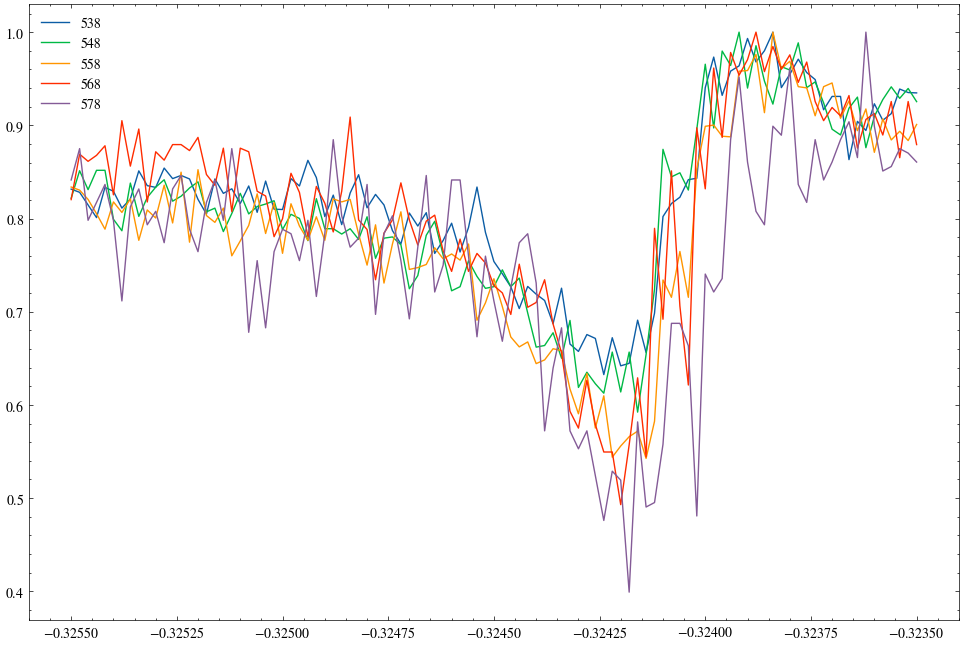

In [6]:
def load_and_extract(run_id):
    dataset = qc.load_by_run_spec(experiment_name="power sweep RT", captured_run_id=run_id)
    data = dataset.get_parameter_data()
    countrate = data["countrate"]["countrate"]
    voltage = data["countrate"]["keysight_ch2_source_voltage"]
    power = data["pm_mobile_power"]["pm_mobile_power"]
    return countrate, voltage, power


plt.figure(figsize=(12, 8))
for i in range(538, 584, 10):
    countrate, voltage, power = load_and_extract(i)

    max_value = countrate.max()
    countrate_normalized = countrate / max_value

    plt.plot(voltage, countrate_normalized, label = i)
plt.legend()
plt.show()

So we need a function that can sort out the dips that starts to increase in values again, such that we have a clean sweep.

In [7]:
def sort_dips(start, stop):
    """Filters out the dips where the counts start to increase again"""

    countrate_mean_list = []    
    for run_id in range(start, stop):
        countrate, voltage, power = load_and_extract(run_id)
        countrate_mean_list.append(np.mean(countrate))
    countrate_mean_arr = np.array(countrate_mean_list) 

    new_stop = np.argmin(countrate_mean_arr) + start 

    return new_stop, countrate_mean_arr

In [8]:
dataset = qc.load_by_run_spec(experiment_name="power sweep RT", captured_run_id=167)
data = dataset.get_parameter_data()

#dataset.snapshot["station"]

In [9]:
new_stop, countrates_avg = sort_dips(167, 226) # So 537 to 587 is okay, 106 to 165 is good, 167 to 226 is also good. 

In [10]:
def power_on_chip(power, attenuation):
    return attenuation * power

In [11]:
test_array = np.linspace(3e-6,30e-6, 25)

In [12]:
def photon_flux_per_lifetime(power, lifetime, wavelength, power_attenuation):
    h = 6.62607015e-34
    c = 3e8
    frequency = c / wavelength
    on_chip_power = power_on_chip(power, power_attenuation)
    return (on_chip_power * lifetime) / (h * frequency)

#photon_flux_per_lifetime(test_array, 150e-12, 1300e-9, 0.0007571)

In [13]:
def fano_dip(x, I0, x0, gamma, q, y0):
    epsilon = 2*(x - x0) / gamma
    return y0 + I0 * ((q + epsilon)**2 / (1 + epsilon**2))    

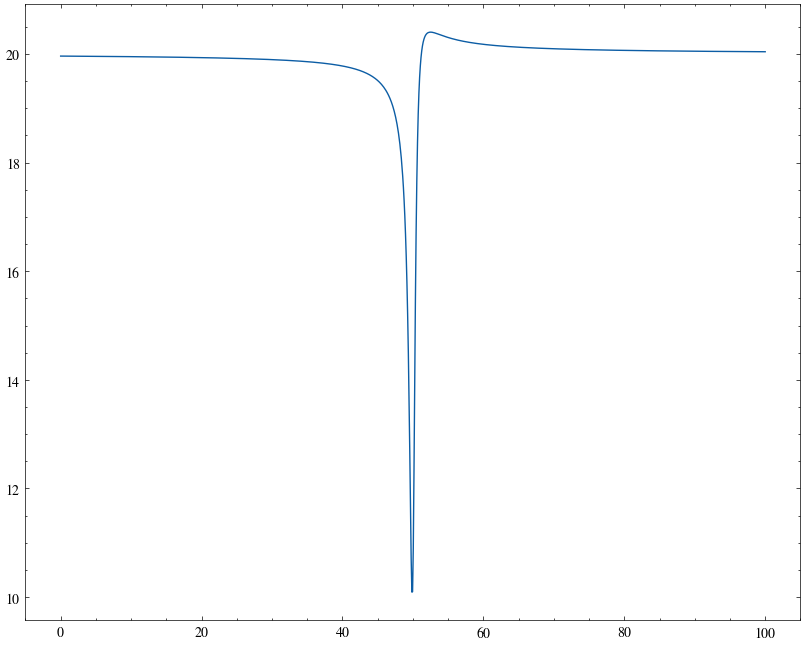

In [14]:
# Testing the fano dip function with varous parameters
x = np.linspace(0, 100, 1000)
I0 = 10
x0 = 50
gamma = 1
q = 0.2
y0 = 10                      
plt.figure(figsize = (10,8))
plt.plot(x, fano_dip(x, I0, x0, gamma, q, y0))
#plt.xlim(25, 50)
plt.show()

In [15]:
def fit_fano(run_id):
    countrate, voltage, power = load_and_extract(run_id)
    
    #y = savgol_filter(np.array(countrate), window_length = 2, polyorder = 1)
    y = countrate

    x = np.array(voltage)
    v_res_arg = np.argmin(countrate)
    v_res = voltage[v_res_arg]
    
    detuning_x = ((voltage - v_res)) * 3994
    x = detuning_x


    sigma_y = np.sqrt(countrate) / np.max(countrate)




    #y = y / np.max(y)

    #Trying to utilize a background instead of a np.max 

    background_level = np.percentile(y, 95)
    y = y / background_level




    I0_guess = max(y) - min(y)
    x0_guess = x[np.argmin(y)]
    gamma_guess = (x.max() - x.min()) / 10
    q_guess = 1.0
    y0_guess = min(y) 

    p0 = [I0_guess, x0_guess, gamma_guess, q_guess, y0_guess]

    try:
        params, covariance = curve_fit(
            fano_dip, x, y, p0=p0, sigma = sigma_y, maxfev=5000, absolute_sigma = False
        )
    except RuntimeError:
        print(f"Fit failed for run {run_id}")
        return None  
    except ValueError:
        print(f"Invalid values for run {run_id}")
        return None

    I0_fit, x0_fit, gamma_fit, q_fit, y0_fit = params
    

    y_fit = fano_dip(x, *params)
    
    
    perr = np.sqrt(np.diag(covariance))
    y0_err = perr[4]
    gamma_err = perr[2]
    print("gamma_err:", gamma_err)

    
    chi2 = np.sum((y - y_fit)**2 / sigma_y**2)
    dof = len(y) - len(params)
    
    
    chi2_red = chi2 / dof

    #y0_err = y0_err * chi2_red

    perr_corrected = perr * np.sqrt(chi2_red)
    y_err_corrected = perr_corrected[4]

    #print(f"Run {run_id}")
    #print("gamma_fit", gamma_fit)
    #print("y_min_fit:", y0_fit)
    #print("y_err:", y0_err)
    #print("Chi²_reduced:", chi2_red)
    #print("y0_err_chi2_corrected:", y_err_corrected)
    
    #plt.figure(figsize = (8,6))
    #plt.plot(x, y, ".", label='Data')
    #plt.errorbar(x, y, yerr = sigma_y, fmt = ".")
    #plt.plot(x, y_fit, 'r-', label=fr"$\Gamma_{{\mathrm{{RT}}}} = {gamma_fit:.3f} \pm {gamma_err:.3f}\,\mathrm{{GHz}}$")
    #plt.legend(prop = {"size": 16}) # prop = {"size": 20}
    #plt.xlabel("Detuning (GHz)", fontsize = 18)
    #plt.ylabel("Normalized Transimssion", fontsize = 18)
    #plt.xticks(fontsize = 18)
    #plt.yticks(fontsize = 18)
    #plt.savefig(f"Dip_plots/dip_plot{run_id}.png", dpi = 300)
    #plt.show()
    
    return power[0], y0_fit.min(), gamma_fit, y0_err, gamma_err # sigma_res

In [16]:
def get_dip_and_power(start, stop):
    dip_min_list = []
    power_list = []
    err_list = []
    gamma_list = []
    gamma_err_list = []
    new_stop, countrates_avg = sort_dips(start, stop)
    print(new_stop)
    for i in range(start, new_stop): 
        result = fit_fano(i)
        if result is None:
            continue
        power, dip_min, gamma_fit, dip_err, gamma_err = result
        gamma_list.append(gamma_fit)
        dip_min_list.append(dip_min)
        power_list.append(power)
        err_list.append(dip_err)
        gamma_err_list.append(gamma_err)

    return np.array(power_list), np.array(dip_min_list), np.array(err_list), np.array(gamma_list), np.array(gamma_err_list)

In [17]:
power_arr, dip_arr, dip_err, gamma_arr, gamma_err_arr = get_dip_and_power(167, 226) # 167 to 219 so good, but check the fitting for the outlier

power_arr_corrected = power_arr[::-1]


215
gamma_err: 0.21489937099092937
gamma_err: 0.2050784122002428
gamma_err: 0.28838715220977656
gamma_err: 0.2724543225170863
gamma_err: 0.2349663579918694
gamma_err: 0.3022631508693207
gamma_err: 0.2534921767869019
gamma_err: 0.31742555217818685
Fit failed for run 175
gamma_err: 0.23051003147863725
gamma_err: 0.3264765370674123
gamma_err: 0.21442162213332494
gamma_err: 0.21746378580545833
gamma_err: 0.19434261358980867
gamma_err: 0.21874839869344537
gamma_err: 0.23547268251725886
gamma_err: 0.2941623440548032
gamma_err: 0.13963262355366263
gamma_err: 0.10737912595464186
gamma_err: 0.15277607591883421
gamma_err: 0.155745793546882
gamma_err: 0.16854211160131038
gamma_err: 0.15995483403909758
gamma_err: 0.12878991285854435
gamma_err: 0.17348132328674845
gamma_err: 0.16946378584397997
gamma_err: 0.11095428808168499
gamma_err: 0.12739453153390862
gamma_err: 0.10859078516073097
gamma_err: 0.11910162714331676
gamma_err: 0.11953613731805811
gamma_err: 0.08940740610122608
gamma_err: 0.08618616

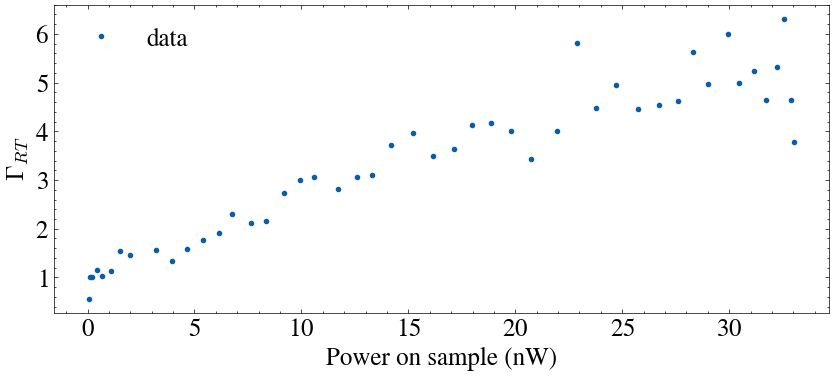

In [18]:
plt.figure(figsize = (10, 4))
plt.plot(power_arr_corrected, np.abs(gamma_arr), ".", label = "data")
plt.legend()
plt.xlabel("Power on sample (nW)", fontsize = 18)
plt.ylabel(r"$\Gamma_{RT}$", fontsize = 18)
#plt.xscale("log")
plt.legend(fontsize = 18)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.savefig("Sweep_plots/Gamma_sweep_no_fit.png", dpi = 300)
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
C:\Users\emile\AppData\Local\Temp\ipykernel_30740\4089048047.py:4: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("Transmission for $\Delta = 0$", fontsize = 18)


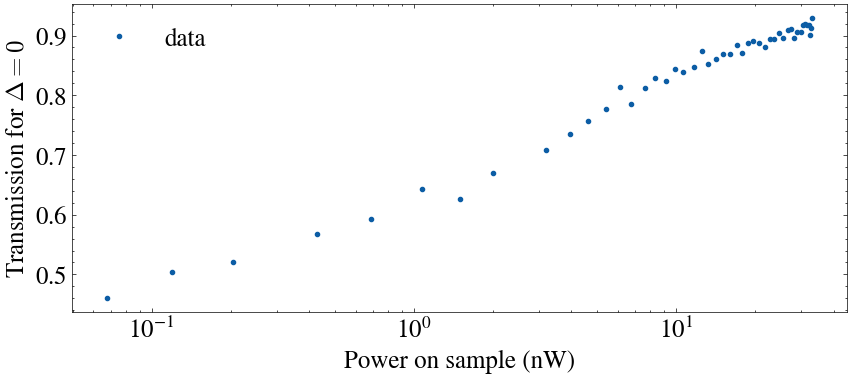

In [19]:
plt.figure(figsize = (10,4))
plt.plot(power_arr_corrected, dip_arr, ".", label = "data")
plt.xlabel("Power on sample (nW)", fontsize = 18)
plt.ylabel("Transmission for $\Delta = 0$", fontsize = 18)
#plt.gca().invert_xaxis()
#plt.xlim(35, 25)
plt.xscale("log")
plt.legend(prop = {"size": 18})
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.savefig(f"Sweep_plots/power_sweep_no_fit.png", dpi = 300)
plt.show()

### Calculating power on chip 

The excitation breadboard has a 50 percent coupling efficiency. 

The power at the first beamsplitter cube is 7.207 uW and the power after the final beamsplitter is 3.087 uW


Going through the entire setup we first before the cube (at full power towards the dot) have 34 uW. Then we have various filters, and then we have the 50 percent coupling efficiency. Then we get the 7.2 uW at the first beamsplitter, which is half. then another beamsplitter, so now 3.1 uW. Then we have the 10:90 beamsplitter (10 percent transmission), meaning 0.31 uW.

So what's the loss from the external breadboard to the first beamsplitter powermeter. So after the external we have 34/2 = 17, but right before the BS we have 7.207*2 = 14.414, so we have  

 14.414 / 17 = 0.84788 percent transmitted in that part of the setup. 

Now between the first BS and the 10:90 we also have another BS. so transmission should be 7.2027 * 0.5 * 0.9 = 3.241215 meaning we from the first BS we transmit 3.087 / 3.241215 = 0.9524. 


So we have transmission 0.5(External) * 0.84788(To first BS) * 0.5(First BS) * 0.5(second BS) * 0.9524(extra losses) * 0.10(10:90 BS)  * Nenir  * 0.75 (Objective) * grating coupler. 

In [20]:
0.5 * 0.84788 * 0.5 * 0.5 * 0.9524 * 0.10 * 0.75 # This is not including grating couplers

0.0075705085500000005

In [21]:
attenuation_1 = 0.007571 * 10**(-1) 

In [22]:
def power_on_chip(power, attenuation):
    return attenuation * power * 10**(3) # from uW to nW so  

In [23]:
print(power_arr_corrected)

[33.0092662  32.9000359  32.5661094  32.2212509  31.7265985  31.1570438
 30.4751356  29.9586318  28.9958516  28.3030222  27.6101928  26.7035848
 25.7267566  24.7109183  23.7762233  22.8805384  21.9676876  20.7521171
 19.7830905  18.8733629  17.9636336  17.1366064  16.148857   15.2079183
 14.2108074  13.3088797  12.6191699  11.7234858  10.610901    9.92431342
  9.19091326  8.33736067  7.62736636  6.76913032  6.13990596  5.39283928
  4.63271499  3.951091    3.21101902  2.00290378  1.50361564  1.07956282
  0.69001885  0.42584435  0.20383028  0.11908101  0.06765331]


In [24]:
power_arr_corrected = power_on_chip(power_arr_corrected, attenuation_1) # nW

In [25]:
print(power_arr_corrected)

[24.99131544 24.90861718 24.65580143 24.39470906 24.02020772 23.58899786
 23.07272516 22.68168014 21.95275925 21.42821811 20.90367697 20.21728405
 19.47772742 18.70863624 18.00097866 17.32285562 16.63173628 15.71142786
 14.97777782 14.28902305 13.600267   12.97412471 12.22629963 11.51391494
 10.75900228 10.07615282  9.55397353  8.8758511   8.03351315  7.51369769
  6.95844043  6.31221576  5.77467907  5.12490857  4.6485228   4.08291862
  3.50742852  2.991371    2.4310625   1.51639845  1.1383874   0.81733701
  0.52241327  0.32240676  0.15431991  0.09015624  0.05122032]


We now want to calculate the pure dephasing, as in "Quantum Optics with Near-Lifetime-Limited Quantum-Dot Transitions in a Nanophotonic Waveguide"

In [26]:
# Trying to do the power sweep again 

3/(np.pi*2)

print(0.076/0.5)

0.152


In [27]:
def power_sweep_fit_full(P, P_sat):
    beta = 0.85
    gamma_RT = 5
    gamma_deph = 2.5
    gamma_r = gamma_deph/gamma_RT
    return 1 + ((beta - 2) * beta) / ((1 + 2*gamma_r) * (1 + (P/P_sat)))

In [28]:
P_sat_guess = 4
p0 = [P_sat_guess]


params, covariance = curve_fit(power_sweep_fit_full, power_arr_corrected, dip_arr, sigma = dip_err, p0=p0, maxfev=5000)
P_sat_fit = params[0]
print(params)
print(covariance)

[4.58084018]
[[0.01098158]]


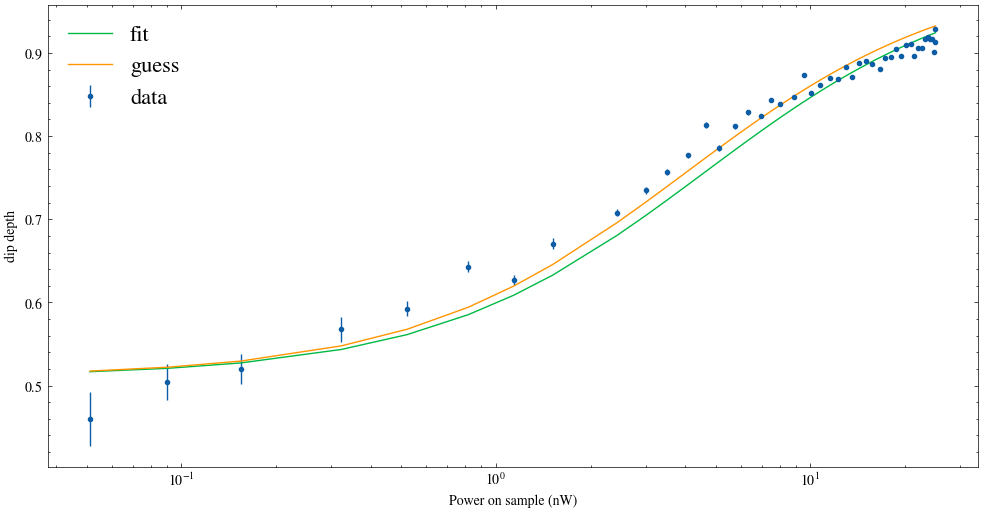

In [29]:
plt.figure(figsize = (12,6))
plt.errorbar(power_arr_corrected, dip_arr, dip_err, fmt = ".", label = "data")
plt.plot(power_arr_corrected, power_sweep_fit_full(power_arr_corrected, *params), label = "fit")
plt.plot(power_arr_corrected, power_sweep_fit_full(power_arr_corrected, *p0), label = "guess")
#plt.axvline(params[0], ymin=0, color = "purple", linestyle = "--", label = fr"$P_{{sat}} = {P_sat_fit:.3f}$")
plt.legend()
plt.xlabel("Power on sample (nW)")
plt.ylabel("dip depth")
plt.xscale("log")
plt.legend(fontsize = 16)
plt.show()

In [30]:
# Trying a fit with beta and gamma being free parameters 

def power_sweep_fit_full(P, beta, gamma_r, P_sat):
    return 1 + ((beta - 2) * beta) / ((1 + 2*gamma_r) * (1 + (P/P_sat)))


In [31]:
P_sat_guess = 4 # 8
beta = 0.8 # 0.7
gamma_r = 0.5 # 0.194 
p0 = [beta, gamma_r, P_sat_guess]


params, covariance = curve_fit(power_sweep_fit_full, power_arr_corrected, dip_arr, sigma=None, p0=p0, maxfev=5000)
perr = np.sqrt(np.diag(covariance))
print(params)
print(perr)
beta_fit = params[0]
n_c_fit = params[2]

[0.84214146 0.50917382 4.0640023 ]
[6.06764009e+05 1.98927164e+05 2.01182448e-01]


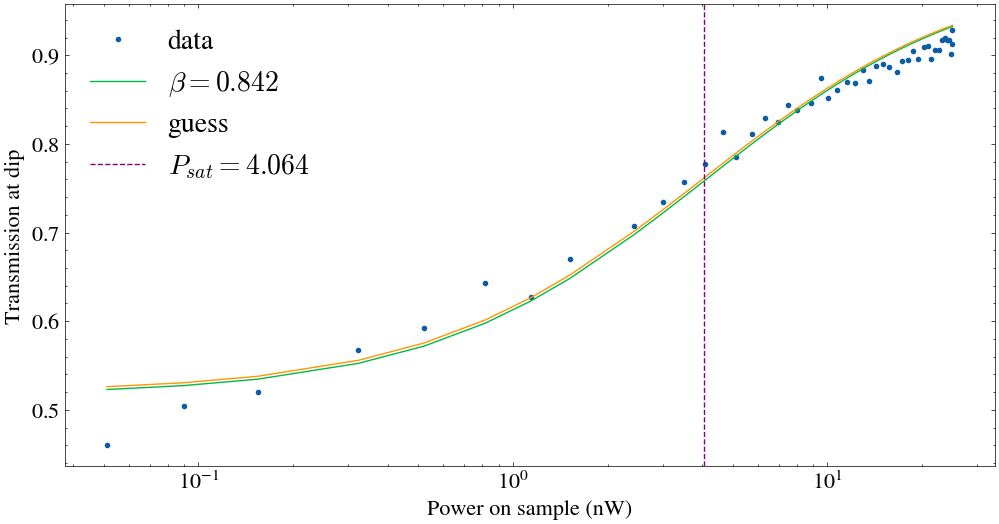

In [32]:
plt.figure(figsize = (12,6))
#plt.errorbar(power_arr_corrected, dip_arr, dip_err, fmt = ".", label = "data")
plt.plot(power_arr_corrected, dip_arr, ".", label = "data")
plt.plot(power_arr_corrected, power_sweep_fit_full(power_arr_corrected, *params), label = fr"$\beta = {beta_fit:.3f}$")
plt.plot(power_arr_corrected, power_sweep_fit_full(power_arr_corrected, *p0), label = "guess")

plt.axvline(params[2], ymin=0, color = "purple", linestyle = "--", label = fr"$P_{{sat}} = {n_c_fit:.3f}$")
plt.xlabel("Power on sample (nW)", fontsize = 16)
plt.ylabel("Transmission at dip", fontsize = 16)
#plt.gca().invert_xaxis()
#plt.xlim(35, 25)
plt.xscale("log")
plt.legend(prop = {"size": 20})
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
#plt.savefig(f"Sweep_plots/power_sweep_no_err.png", dpi = 300)
plt.show()

In [33]:
# Let try to fit the full model to see if it's easier to fit the model. Note that we must set the detuning between the laser and the dot to zero

def power_sweep_fit_advanced(P, beta, gamma, gamma_deph, epsilon, P_sat):
    return   1 - ( (gamma + 2*gamma_deph)*((beta-1)**2 *gamma + 2*gamma_deph ) *(1+epsilon**2) ) / ( ((gamma + 2 * gamma_deph)**2 + (((beta - 1)*gamma - 2*gamma_deph )**2)*epsilon**2) * (1 + (P/P_sat)) ) 

In [34]:
P_sat_guess = 5
beta = 0.75   # 0.75
gamma = 4.5/(2*np.pi) # 4.5
gamma_deph = 1/(2*np.pi) # 1
epsilon = 0.2 #  0.2
p0 = [beta, gamma, gamma_deph, epsilon, P_sat_guess]


params, covariance = curve_fit(power_sweep_fit_advanced, power_arr_corrected, dip_arr, sigma = None, p0=p0, maxfev=5000, absolute_sigma=True)
perr = np.sqrt(np.diag(covariance))
print(params)
print(perr)
beta_fit = params[0]
n_c_fit = params[4]

[0.72044278 0.58992095 0.18746876 0.40483969 4.06401264]
[3.01975303e+07 2.64773939e+07 6.83360675e+06 2.03245873e+07
 1.06698701e+01]


<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
C:\Users\emile\AppData\Local\Temp\ipykernel_30740\403324534.py:9: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("Transmission for $\Delta = 0$", fontsize = 18)


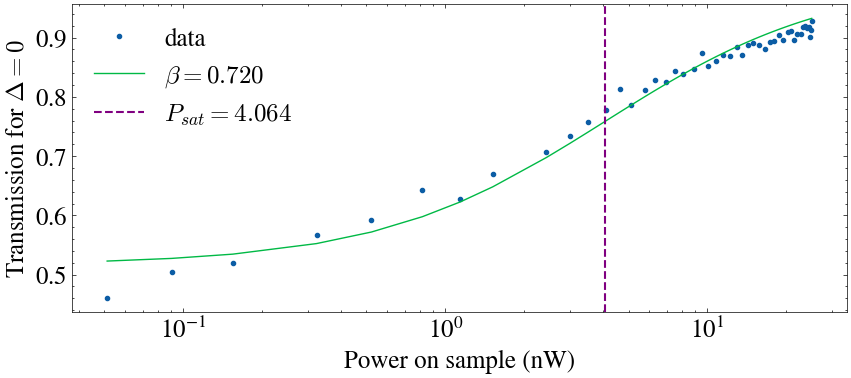

In [35]:
plt.figure(figsize = (10,4))
plt.plot(power_arr_corrected, dip_arr, ".", label = "data")
#plt.errorbar(power_arr_corrected, dip_arr, dip_err, fmt = ".", label = "data")
plt.plot(power_arr_corrected, power_sweep_fit_advanced(power_arr_corrected, *params), label = fr"$\beta = {beta_fit:.3f}$")
#plt.plot(power_arr_corrected, power_sweep_fit_advanced(power_arr_corrected, *p0), label = "guess")

plt.axvline(params[4], ymin=0, color = "purple", linestyle = "--", linewidth = 1.5, label = fr"$P_{{sat}} = {n_c_fit:.3f}$")
plt.xlabel("Power on sample (nW)", fontsize = 18)
plt.ylabel("Transmission for $\Delta = 0$", fontsize = 18)
#plt.gca().invert_xaxis()
#plt.xlim(35, 25)
plt.xscale("log")
plt.legend(prop = {"size": 18})
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
#plt.savefig(f"Sweep_plots/power_sweep_with_err.png", dpi = 300)
plt.show()

In [36]:
print(5.2/(2*np.pi))
print(1.44/(2*np.pi))
print("gamma_r", (2.7/5.4))

0.8276057040778558
0.22918311805232927
gamma_r 0.5


In [37]:
def power_sweep_fit_advanced(P, beta, gamma, gamma_deph, epsilon, P_sat):
    return   1 - ( (gamma + 2*gamma_deph)*((beta-1)**2 *gamma + 2*gamma_deph ) *(1+epsilon**2) ) / ( ((gamma + 2 * gamma_deph)**2 + (((beta - 1)*gamma - 2*gamma_deph )**2)*epsilon**2) * (1 + (P/P_sat)) ) 

In [38]:
# We will now try to fit the gamma vs power sweep. 

def gamma_RT_power_sweep(P, Gamma, Gamma_deph, P_sat):
    return (Gamma + 2* (Gamma_deph)) * np.sqrt((1 + np.abs((P/P_sat))) ) 

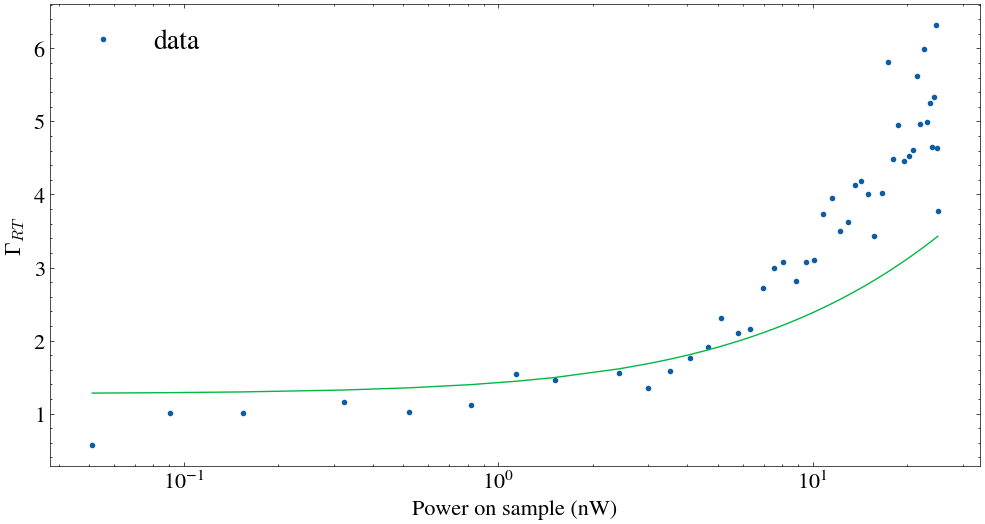

In [39]:
plt.figure(figsize = (12,6))
#plt.errorbar(power_arr_corrected, gamma_arr, gamma_err_arr, fmt = ".", label = "data")
plt.plot(power_arr_corrected, np.abs(gamma_arr), ".", label = "data")
plt.plot(power_arr_corrected, gamma_RT_power_sweep(power_arr_corrected, 5.2/(np.pi*2), 1.4/(np.pi*2), 4))
#plt.plot(power_arr_corrected, gamma_RT_power_sweep(power_arr_corrected, 4.5/(np.pi*2), 1.0/(np.pi*2), 4), label = "lower")
#plt.axvline(params[4], ymin=0, color = "purple", linestyle = "--", linewidth = 1.5, label = fr"$P_{{sat}} = {n_c_fit:.3f}$")
plt.legend()
plt.xlabel("Power on sample (nW)", fontsize = 16)
plt.ylabel(r"$\Gamma_{RT}$", fontsize = 16)
plt.xscale("log")
plt.legend(fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
#plt.savefig("Sweep_plots/Gamma_sweep.png", dpi = 300)
plt.show()

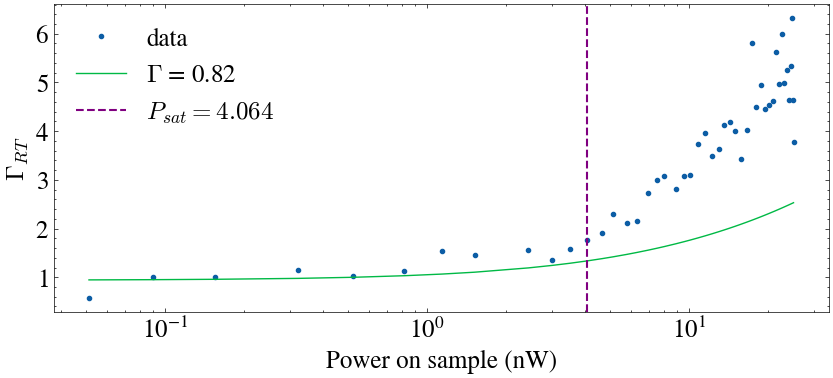

In [40]:
# Making a gamma plot with different parameters inserted 


plt.figure(figsize = (10, 4))
#plt.errorbar(power_arr_corrected, gamma_arr, gamma_err_arr, fmt = ".", label = "data")
plt.plot(power_arr_corrected, np.abs(gamma_arr), ".", label = "data")
plt.plot(power_arr_corrected, gamma_RT_power_sweep(power_arr_corrected, 0.58, 0.18, 4), label = r"$\Gamma$ = 0.82") # 5.2/(np.pi*2), 1.44/(np.pi*2)
#plt.plot(power_arr_corrected, gamma_RT_power_sweep(power_arr_corrected, 8/(np.pi*2), 1.44/(np.pi*2), 4), label = r"$\Gamma$ = 1.27")
#plt.plot(power_arr_corrected, gamma_RT_power_sweep(power_arr_corrected, 2.5/(np.pi*2), 1.44/(np.pi*2), 4), label = r"$\Gamma$ = 0.39")
#plt.plot(power_arr_corrected, gamma_RT_power_sweep(power_arr_corrected, 4.5/(np.pi*2), 1.0/(np.pi*2), 4), label = "lower")
plt.axvline(params[4], ymin=0, color = "purple", linestyle = "--", linewidth = 1.5, label = fr"$P_{{sat}} = {n_c_fit:.3f}$")
plt.legend()
plt.xlabel("Power on sample (nW)", fontsize = 18)
plt.ylabel(r"$\Gamma_{RT}$", fontsize = 18)
plt.xscale("log")
plt.legend(fontsize = 18)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
#plt.savefig("Sweep_plots/Gamma_sweep.png", dpi = 300)
plt.show()

In [41]:
def power_sweep_fit_advanced_freq(P, beta, Gamma, Gamma_deph, epsilon, P_sat):
    return 1 - (
        (Gamma + 2*Gamma_deph) *
        ((beta - 1)**2 * Gamma + 2*Gamma_deph) *
        (1 + epsilon**2)
    ) / (
        (
            (Gamma + 2*Gamma_deph)**2 +
            (((beta - 1)*Gamma - 2*Gamma_deph)**2) * epsilon**2
        ) *
        (1 + P / P_sat)
    )

In [42]:
P_sat_guess = 5
beta = 0.8   # 0.75
Gamma = 2 # 4.5
Gamma_deph = 1 # 1
epsilon = 0.4 #  0.2
p0_freq = [beta, Gamma, Gamma_deph, epsilon, P_sat_guess]


params, covariance = curve_fit(power_sweep_fit_advanced_freq, power_arr_corrected, dip_arr, sigma = None, p0=p0_freq, maxfev=5000, absolute_sigma=True)
perr = np.sqrt(np.diag(covariance))
print(params)
print(perr)
beta_fit = params[0]
n_c_fit = params[4]

[0.83162081 2.10277968 0.5951932  0.61547339 4.06401093]
[4.14440989e+07 7.64915577e+07 2.53991280e+07 3.01262045e+07
 1.01943943e+01]


<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
C:\Users\emile\AppData\Local\Temp\ipykernel_30740\2194026818.py:9: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("Transmission for $\Delta = 0$", fontsize = 18)


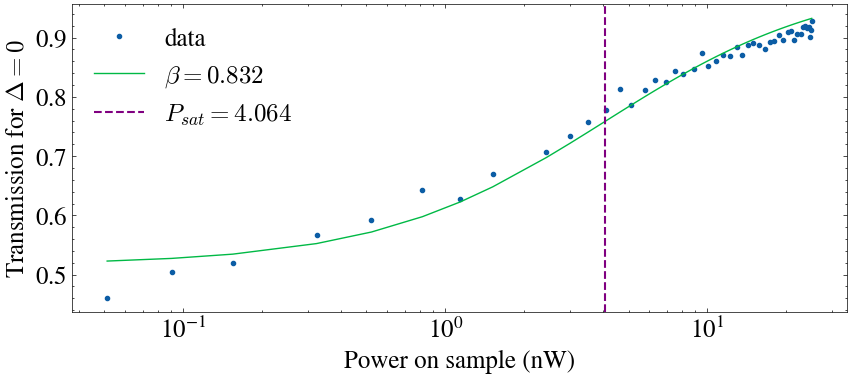

In [43]:
plt.figure(figsize = (10,4))
plt.plot(power_arr_corrected, dip_arr, ".", label = "data")
#plt.errorbar(power_arr_corrected, dip_arr, dip_err, fmt = ".", label = "data")
plt.plot(power_arr_corrected, power_sweep_fit_advanced(power_arr_corrected, *params), label = fr"$\beta = {beta_fit:.3f}$")
#plt.plot(power_arr_corrected, power_sweep_fit_advanced(power_arr_corrected, *p0), label = "guess")

plt.axvline(params[4], ymin=0, color = "purple", linestyle = "--", linewidth = 1.5, label = fr"$P_{{sat}} = {n_c_fit:.3f}$")
plt.xlabel("Power on sample (nW)", fontsize = 18)
plt.ylabel("Transmission for $\Delta = 0$", fontsize = 18)
#plt.gca().invert_xaxis()
#plt.xlim(35, 25)
plt.xscale("log")
plt.legend(prop = {"size": 18})
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.savefig(f"Sweep_plots/power_sweep_with_err.png", dpi = 300)
plt.show()

In [44]:
gamma_emil = 4.5 /(np.pi*2)
gamma_deph_emil = 1.3/(np.pi*2) 
P_sat_emil = 2
p0 = [gamma_emil, gamma_deph_emil, P_sat_emil]

bounds = (
    [0.0, 0.0, 0],   # lower bounds
    [10.0, 10.0, 8]   # upper bounds
)
params, covariance = curve_fit(gamma_RT_power_sweep, power_arr_corrected, gamma_arr, sigma = None, bounds = bounds, p0=p0, maxfev=5000, absolute_sigma=False)
perr = np.sqrt(np.diag(covariance))
gamma_fit = params[0]
gamma_deph_fit = params[1]
P_sat_fit = params[2]

print("gamma fit:", gamma_fit)
print("gamma_deph:", gamma_deph_fit)
print("P_sat", P_sat_fit)

gamma fit: 0.39957009692719936
gamma_deph: 0.12085283548158095
P_sat 0.38315019995713984


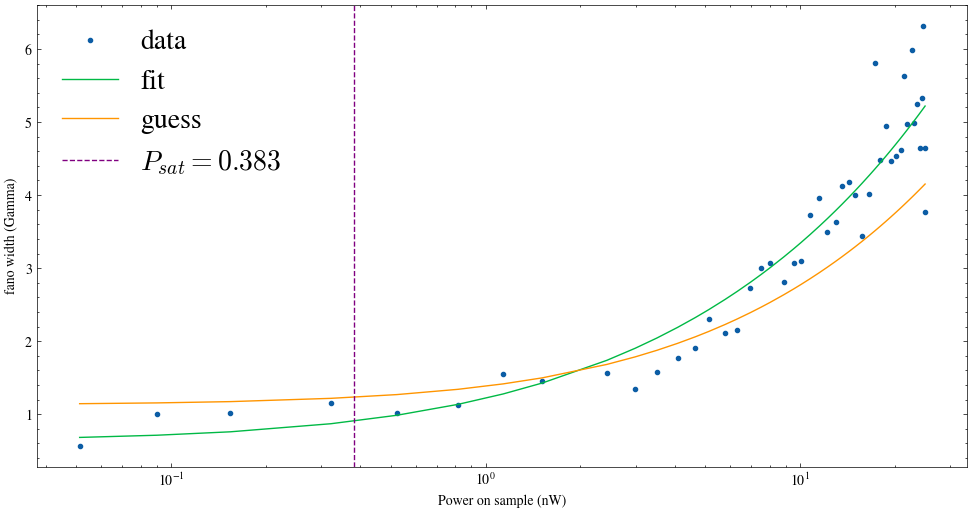

In [45]:
plt.figure(figsize = (12,6))
plt.plot(power_arr_corrected, gamma_arr, ".", label = "data")
plt.plot(power_arr_corrected, gamma_RT_power_sweep(power_arr_corrected, *params), label = "fit")
plt.plot(power_arr_corrected, gamma_RT_power_sweep(power_arr_corrected, *p0), label = "guess")
plt.axvline(params[2], ymin=0, color = "purple", linestyle = "--", label = fr"$P_{{sat}} = {P_sat_fit:.3f}$")
plt.legend()
plt.xlabel("Power on sample (nW)")
plt.ylabel("fano width (Gamma)")
plt.xscale("log")
plt.legend(fontsize = 20)
plt.show()

gamma fit: 0.5617192661052515
gamma_deph: 0.16850798660541108
P_sat: 1.3674115781384197


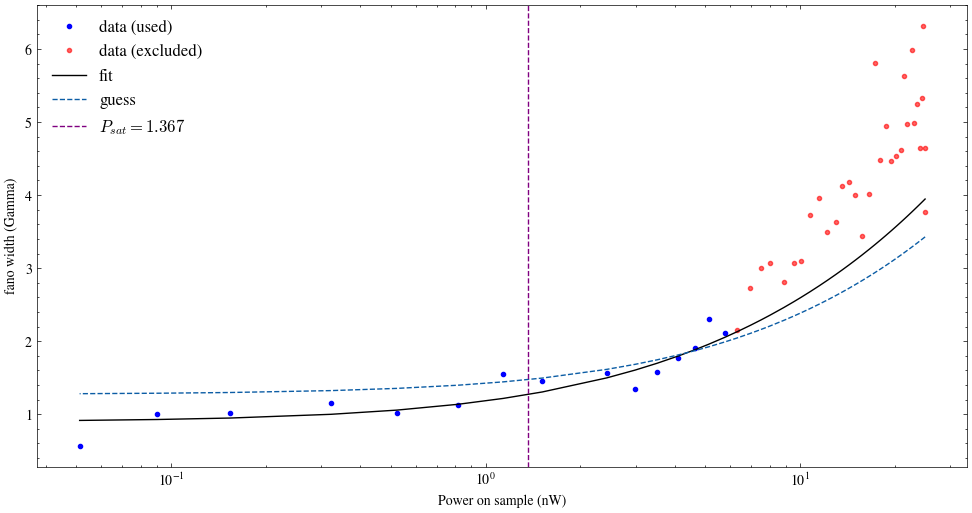

In [47]:

gamma = 5  /(np.pi*2)
gamma_deph = 1.5 /(np.pi*2)
P_sat = 4

p0 = [gamma, gamma_deph, P_sat]

cutoff = 6

mask = power_arr_corrected < cutoff

power_fit = power_arr_corrected[mask]
gamma_fit_data = gamma_arr[mask]
gamma_err_fit = gamma_err_arr[mask] 


power_removed = power_arr_corrected[~mask]
gamma_removed = gamma_arr[~mask]



lower_bounds = [0, 0, 0]        
upper_bounds = [4, 2, 10]

params, covariance = curve_fit(
    gamma_RT_power_sweep,
    power_fit,
    gamma_fit_data,
    sigma=gamma_err_fit,
    p0=p0,
    bounds = (lower_bounds, upper_bounds),
    maxfev=5000,
    absolute_sigma=True
)

perr = np.sqrt(np.diag(covariance))

gamma_fit = params[0]
gamma_deph_fit = params[1]
P_sat_fit = params[2]

print("gamma fit:", gamma_fit)
print("gamma_deph:", gamma_deph_fit)
print("P_sat:", P_sat_fit)

plt.figure(figsize=(12, 6))

plt.plot(power_fit, np.abs(gamma_fit_data), ".", color="blue", label="data (used)")

plt.plot(power_removed, np.abs(gamma_removed), ".", color="red", alpha=0.6, label="data (excluded)")

plt.plot(
    power_arr_corrected,
    gamma_RT_power_sweep(np.abs(power_arr_corrected), *params),
    color="black",
    label="fit"
)

plt.plot(
    power_arr_corrected,
    gamma_RT_power_sweep(np.abs(power_arr_corrected), *p0),
    linestyle="--",
    label="guess"
)


plt.axvline(
    P_sat_fit,
    color="purple",
    linestyle="--",
    label=fr"$P_{{sat}} = {P_sat_fit:.3f}$"
)

plt.xlabel("Power on sample (nW)")
plt.ylabel("fano width (Gamma)")
plt.xscale("log")
plt.legend(fontsize=12)
plt.savefig(f"Sweep_plots/gamma_sweep_with_cutoff.png", dpi = 300)
plt.show()